In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [76]:
# Housing Price Prediction Using Linear Regression

In [77]:
df = pd.read_csv("Housing.csv")

In [78]:
#Check Missing Values

In [79]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [80]:
#Select Features and Target

In [81]:
X = df[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']]
y = df['price']

In [82]:
print("Features:")
print(X.head())

Features:
   area  bedrooms  bathrooms  stories  parking
0  7420         4          2        3        2
1  8960         4          4        4        3
2  9960         3          2        2        2
3  7500         4          2        2        3
4  7420         4          1        2        2


In [83]:
print("\nTarget:") 
print(y.head())


Target:
0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64


In [84]:
#Split Dataset into Training and Testing Data

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (436, 5)
Testing data: (109, 5)


In [86]:
# Create the Linear Regression model

In [87]:
model = LinearRegression()

In [88]:
# Train the model using training data

In [89]:
model.fit(X_train, y_train) 
print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [108]:
# Display coefficients for each feature

In [90]:
coefficients = pd.DataFrame({ 'Feature': X.columns, 'Coefficient': model.coef_ }) 
print(coefficients)

     Feature   Coefficient
0       area  3.088670e+02
1   bedrooms  1.512468e+05
2  bathrooms  1.185732e+06
3    stories  4.951008e+05
4    parking  3.376608e+05


In [ ]:
# Predict house prices using the test data

In [91]:
y_pred = model.predict(X_test)

In [ ]:
# Display the first 10 predictions

In [92]:
print("Predicted Prices:") 
print(y_pred[:10])

Predicted Prices:
[6178627.50326817 6370140.85865473 3283148.1570249  4226007.94816032
 3409685.55116741 4262158.3499693  5493440.53152357 5559897.74293016
 3373715.42245305 3020513.18649699]


In [93]:
# Calculate Mean Absolute Error

In [94]:
mae = mean_absolute_error(y_test, y_pred)

In [95]:
# Calculate Mean Squared Error

In [96]:
mse = mean_squared_error(y_test, y_pred)

In [97]:
# Calculate Root Mean Squared Error

In [98]:
rmse = np.sqrt(mse)

In [99]:
# Calculate R-squared score

In [100]:
r2 = r2_score(y_test, y_pred)

In [101]:
print("Model Evaluation Results") 
print("MAE :", mae) 
print("MSE :", mse) 
print("RMSE:", rmse) 
print("R² Score:", r2)

Model Evaluation Results
MAE : 1127483.3523235186
MSE : 2292721545725.3613
RMSE: 1514173.552049223
R² Score: 0.5464062355495873


In [102]:
# Create a DataFrame containing actual and predicted prices

In [103]:
results = pd.DataFrame({ 'Actual Price': y_test.values, 'Predicted Price': y_pred })

In [104]:
# Display first 10 results

In [105]:
results.head(10)

,Actual Price,Predicted Price
0,4060000,6.178628e+06
1,6650000,6.370141e+06
2,3710000,3.283148e+06
3,6440000,4.226008e+06
4,2800000,3.409686e+06
5,4900000,4.262158e+06
6,5250000,5.493441e+06
7,4543000,5.559898e+06
8,2450000,3.373715e+06
9,3353000,3.020513e+06


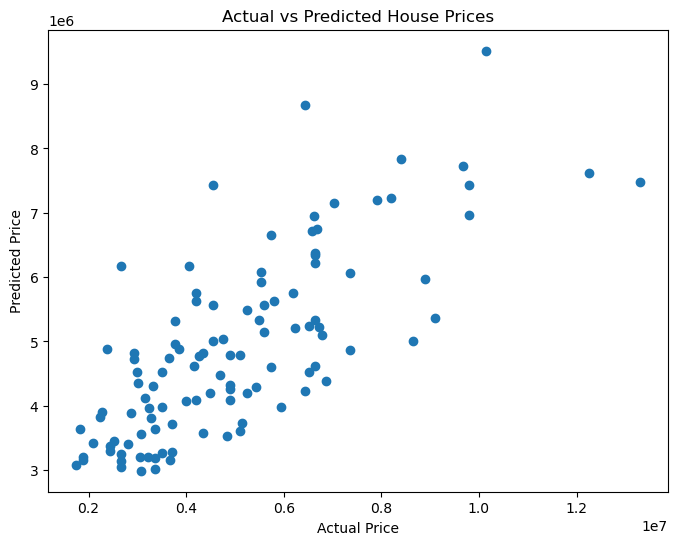

In [106]:
plt.figure(figsize=(8, 6)) 
plt.scatter(y_test, y_pred) 
plt.xlabel("Actual Price") 
plt.ylabel("Predicted Price") 
plt.title("Actual vs Predicted House Prices") 
plt.show()

In [107]:
new_house = pd.DataFrame({ 
  'area': [8000],
  'bedrooms': [6],
  'bathrooms': [3],
  'stories': [2],
  'parking': [3]
})

new_price = model.predict(new_house)

print("Predicted House Price:", new_price[0])

Predicted House Price: 8990794.986608969
